# 01. 건물형 태양광 모델 학습

`building_region_balanced_nonslope_ml(1).csv`를 사용하여 건물형 모델을 학습합니다.

- 전체 2,348건
- 설치 `label=1`: 1,174건
- 미설치 `label=0`: 1,174건
- 건물형 전용 모델로 학습
- `slope_avg`, `slope_dir`, `elevation_avg`, `Hillshade`, `Southness`는 모델 Feature에서 제외
- RandomForest, XGBoost, LightGBM, CatBoost 비교
- 최종 모델을 `Building_model_bundle.pkl`로 저장


In [44]:
!pip -q install xgboost lightgbm catboost shap joblib openpyxl

In [45]:
import json
import shutil
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("라이브러리 로드 완료")


라이브러리 로드 완료


## 1. 파일 업로드 및 설정

In [46]:
# Colab에 파일이 이미 올라가 있다면 False로 변경합니다.
UPLOAD_FILE = True

if UPLOAD_FILE:
    from google.colab import files
    uploaded = files.upload()
    print("업로드 파일:", list(uploaded.keys()))

# 실제 파일명에 맞게 수정
TRAIN_FILENAME = "building_region_balanced_nonslope_ml(1).csv"
TRAIN_PATH = Path("/content") / TRAIN_FILENAME

OUTPUT_DIR = Path("/content/building_model_training_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALID_SIZE = 0.20
SELECTION_METRIC = "ROC-AUC"

# 전력계통 Feature 사용 여부
USE_GRID_FEATURES = True

# 전체 Train 재학습 후 SHAP에 사용할 최대 표본 수
SHAP_SAMPLE_SIZE = 5000

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Train 파일이 없습니다: {TRAIN_PATH}")

print("Train 파일:", TRAIN_PATH)
print("결과 폴더:", OUTPUT_DIR)


업로드 파일: []
Train 파일: /content/Land_Train_dataset.xlsx
결과 폴더: /content/land_model_training_results


## 2. Feature 및 모델 정의

In [47]:
SOLAR_WEATHER_FEATURES = [
    "ghi_avg_daily",
    "pvout_avg_daily",
    "dni_avg_daily",
    "dif_avg_daily",
    "gti_avg_daily",
    "temp_avg",
    "wind_speed_10m",
    "wind_speed_50m",
    "wind_speed_100m",
]

# 건물형은 토지 지형 Feature를 사용하지 않음
BUILDING_FEATURES = SOLAR_WEATHER_FEATURES.copy()

GRID_FEATURES = [
    "distance_to_substation_km",
    "distance_to_powerline_km",
    "substation_count_5km",
    "powerline_length_5km_km",
    "high_voltage_line_nearby_5km",
    "substation_max_voltage_kv",
    "powerline_max_voltage_kv",
    "substation_max_voltage_kv_missing",
    "powerline_max_voltage_kv_missing",
]

METADATA_COLUMNS = [
    "source_id_ml",
    "address_ml",
    "longitude",
    "latitude",
    "시도",
    "시군구",
    "자산구분_ML",
    "설치구분",
    "region_group",
]

FEATURE_KOREAN_NAMES = {
    "ghi_avg_daily": "수평면 전일사량",
    "pvout_avg_daily": "예상 태양광 발전량",
    "dni_avg_daily": "직달일사량",
    "dif_avg_daily": "산란일사량",
    "gti_avg_daily": "경사면 일사량",
    "temp_avg": "평균 기온",
    "wind_speed_10m": "10m 높이 풍속",
    "wind_speed_50m": "50m 높이 풍속",
    "wind_speed_100m": "100m 높이 풍속",
    "distance_to_substation_km": "최근접 변전소 거리",
    "distance_to_powerline_km": "최근접 전력선 거리",
    "substation_count_5km": "5km 이내 변전소 수",
    "powerline_length_5km_km": "5km 이내 전력선 길이",
    "high_voltage_line_nearby_5km": "5km 이내 고압선 존재",
    "substation_max_voltage_kv": "인근 변전소 최대 전압",
    "powerline_max_voltage_kv": "인근 전력선 최대 전압",
    "substation_max_voltage_kv_missing": "변전소 전압 결측 여부",
    "powerline_max_voltage_kv_missing": "전력선 전압 결측 여부",
}

FEATURE_COLUMNS = BUILDING_FEATURES.copy()

if USE_GRID_FEATURES:
    FEATURE_COLUMNS += GRID_FEATURES

TARGET_COLUMN = "label"


def make_models():
    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        ),
        "CatBoost": CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        ),
    }


def extract_positive_class_values(shap_result):
    values = shap_result.values

    if isinstance(values, list):
        values = values[-1]

    values = np.asarray(values)

    if values.ndim == 3:
        values = values[:, :, 1]

    return values


## 3. Train 데이터 로드 및 검증

In [48]:
suffix = TRAIN_PATH.suffix.lower()

if suffix in [".xlsx", ".xls"]:
    train_df = pd.read_excel(TRAIN_PATH)
elif suffix == ".csv":
    train_df = pd.read_csv(TRAIN_PATH)
else:
    raise ValueError(
        "Train 파일은 xlsx, xls 또는 csv 형식이어야 합니다."
    )

print("Train 크기:", train_df.shape)
print("컬럼 수:", len(train_df.columns))

if "source_id_ml" in train_df.columns:
    print(
        "ID 중복:",
        train_df["source_id_ml"]
        .astype(str)
        .duplicated()
        .sum(),
    )

required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]

missing_columns = [
    col for col in required_columns
    if col not in train_df.columns
]

if missing_columns:
    raise KeyError(f"Train 필수 컬럼 누락: {missing_columns}")

for col in FEATURE_COLUMNS:
    train_df[col] = pd.to_numeric(
        train_df[col],
        errors="coerce",
    )

train_df[TARGET_COLUMN] = pd.to_numeric(
    train_df[TARGET_COLUMN],
    errors="raise",
).astype(int)

if set(train_df[TARGET_COLUMN].dropna().unique()) != {0, 1}:
    raise ValueError("label에는 0과 1이 모두 있어야 합니다.")

print("\n라벨 분포")
display(
    train_df[TARGET_COLUMN]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("건수")
)

# 값이 전부 같거나 전부 결측인 Feature는 자동 제거
constant_features = [
    col for col in FEATURE_COLUMNS
    if train_df[col].nunique(dropna=False) <= 1
]

FEATURE_COLUMNS = [
    col for col in FEATURE_COLUMNS
    if col not in constant_features
]

print("\n제거된 상수 Feature:", constant_features)
print("최종 Feature 수:", len(FEATURE_COLUMNS))
display(pd.DataFrame({"Feature": FEATURE_COLUMNS}))


Train 크기: (2409, 34)
컬럼 수: 34
ID 중복: 0

라벨 분포


,건수
label,
0,1219
1,1190



제거된 상수 Feature: []
최종 Feature 수: 23


,Feature
0,ghi_avg_daily
1,pvout_avg_daily
2,dni_avg_daily
3,dif_avg_daily
4,gti_avg_daily
5,temp_avg
6,wind_speed_10m
7,wind_speed_50m
8,wind_speed_100m
9,slope_avg


## 4. Train 내부 학습·검증 분할

In [49]:
X_raw = (
    train_df[FEATURE_COLUMNS]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

y = train_df[TARGET_COLUMN].copy()

train_idx, valid_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=VALID_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train_raw = X_raw.iloc[train_idx].copy()
X_valid_raw = X_raw.iloc[valid_idx].copy()
y_train = y.iloc[train_idx].copy()
y_valid = y.iloc[valid_idx].copy()

# 검증 데이터 정보가 Train 전처리에 유입되지 않도록 내부 Train 중앙값만 사용
inner_train_medians = X_train_raw.median(numeric_only=True)

X_train = X_train_raw.fillna(inner_train_medians)
X_valid = X_valid_raw.fillna(inner_train_medians)

remaining_missing = X_train.columns[X_train.isna().any()].tolist()

if remaining_missing:
    raise ValueError(
        "내부 Train에서 중앙값으로 대체할 수 없는 Feature가 있습니다: "
        f"{remaining_missing}"
    )

print("내부 Train:", X_train.shape)
print("Validation:", X_valid.shape)


내부 Train: (1927, 23)
Validation: (482, 23)


## 5. 모델 비교 및 최적 모델 선정


RandomForest
              precision    recall  f1-score   support

           0     0.9114    0.8852    0.8981       244
           1     0.8857    0.9118    0.8986       238

    accuracy                         0.8983       482
   macro avg     0.8986    0.8985    0.8983       482
weighted avg     0.8987    0.8983    0.8983       482


XGBoost
              precision    recall  f1-score   support

           0     0.9079    0.8893    0.8986       244
           1     0.8889    0.9076    0.8981       238

    accuracy                         0.8983       482
   macro avg     0.8984    0.8985    0.8983       482
weighted avg     0.8985    0.8983    0.8983       482


LightGBM
              precision    recall  f1-score   support

           0     0.9020    0.9057    0.9039       244
           1     0.9030    0.8992    0.9011       238

    accuracy                         0.9025       482
   macro avg     0.9025    0.9024    0.9025       482
weighted avg     0.9025    0.9025    0.90

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,LightGBM,0.9025,0.9030,0.8992,0.9011,0.9573,0.9525
1,CatBoost,0.9004,0.8862,0.9160,0.9008,0.9556,0.9514
2,XGBoost,0.8983,0.8889,0.9076,0.8981,0.9552,0.9493
3,RandomForest,0.8983,0.8857,0.9118,0.8986,0.9530,0.9533


선택 모델: LightGBM


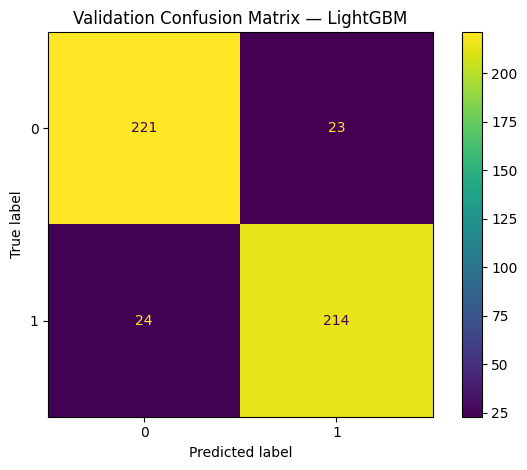

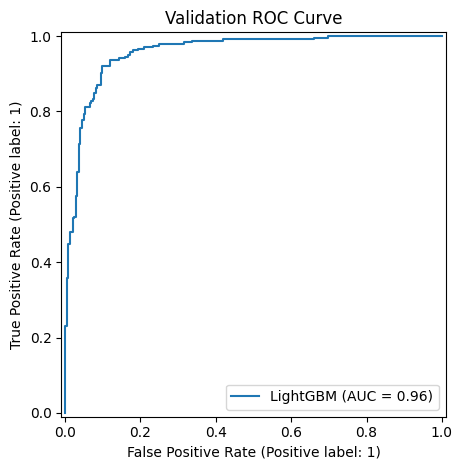

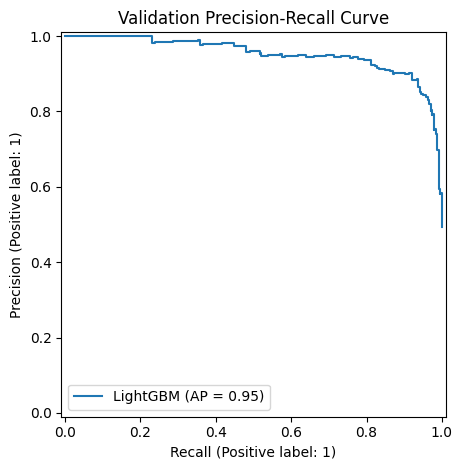

In [50]:
models = make_models()

trained_models = {}
metric_rows = []
validation_predictions = {}

for model_name, model in models.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    prob = model.predict_proba(X_valid)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, pred),
        "Precision": precision_score(y_valid, pred, zero_division=0),
        "Recall": recall_score(y_valid, pred, zero_division=0),
        "F1": f1_score(y_valid, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_valid, prob),
        "PR-AUC": average_precision_score(y_valid, prob),
    }

    metric_rows.append(metrics)
    trained_models[model_name] = model
    validation_predictions[model_name] = {
        "pred": pred,
        "prob": prob,
    }

    print(classification_report(y_valid, pred, digits=4))

model_comparison = (
    pd.DataFrame(metric_rows)
    .sort_values(
        [SELECTION_METRIC, "PR-AUC"],
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\n모델 비교")
display(model_comparison)

best_model_name = model_comparison.loc[0, "Model"]
best_inner_model = trained_models[best_model_name]
best_valid_pred = validation_predictions[best_model_name]["pred"]
best_valid_prob = validation_predictions[best_model_name]["prob"]

print("선택 모델:", best_model_name)

model_comparison.to_csv(
    OUTPUT_DIR / "validation_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    best_valid_pred,
)
plt.title(f"Validation Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

RocCurveDisplay.from_predictions(
    y_valid,
    best_valid_prob,
    name=best_model_name,
)
plt.title("Validation ROC Curve")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_roc_curve.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

PrecisionRecallDisplay.from_predictions(
    y_valid,
    best_valid_prob,
    name=best_model_name,
)
plt.title("Validation Precision-Recall Curve")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_pr_curve.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


## 6. 전체 Train 재학습 및 Model Bundle 저장

In [51]:
# 최종 모델은 전체 Train 데이터로 다시 학습합니다.
full_train_medians = X_raw.median(numeric_only=True)
X_full = X_raw.fillna(full_train_medians)

remaining_missing = X_full.columns[X_full.isna().any()].tolist()

if remaining_missing:
    raise ValueError(
        "전체 Train에서 중앙값으로 대체할 수 없는 Feature가 있습니다: "
        f"{remaining_missing}"
    )

final_model = make_models()[best_model_name]
final_model.fit(X_full, y)

model_bundle = {
    "model": final_model,
    "model_name": best_model_name,
    "dataset_type": "building",
    "model_version": "1.0.0",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "metadata_columns": METADATA_COLUMNS,
    "feature_korean_names": FEATURE_KOREAN_NAMES,
    "train_medians": {
        col: float(full_train_medians[col])
        for col in FEATURE_COLUMNS
    },
    "use_grid_features": USE_GRID_FEATURES,
    "constant_features_removed": constant_features,
    "random_state": RANDOM_STATE,
    "validation_size": VALID_SIZE,
    "selection_metric": SELECTION_METRIC,
    "validation_metrics": model_comparison.to_dict(orient="records"),
    "training_rows": int(len(train_df)),
    "training_label_counts": {
        str(key): int(value)
        for key, value in train_df[TARGET_COLUMN]
        .value_counts()
        .sort_index()
        .items()
    },
}

MODEL_BUNDLE_PATH = OUTPUT_DIR / "Building_model_bundle.pkl"
joblib.dump(model_bundle, MODEL_BUNDLE_PATH)

config_for_json = {
    key: value
    for key, value in model_bundle.items()
    if key != "model"
}

with open(
    OUTPUT_DIR / "Building_model_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        config_for_json,
        f,
        ensure_ascii=False,
        indent=2,
    )

print("모델 Bundle 저장:", MODEL_BUNDLE_PATH)


모델 Bundle 저장: /content/land_model_training_results/Land_model_bundle.pkl


## 7. 최종 모델 전역 SHAP 분석

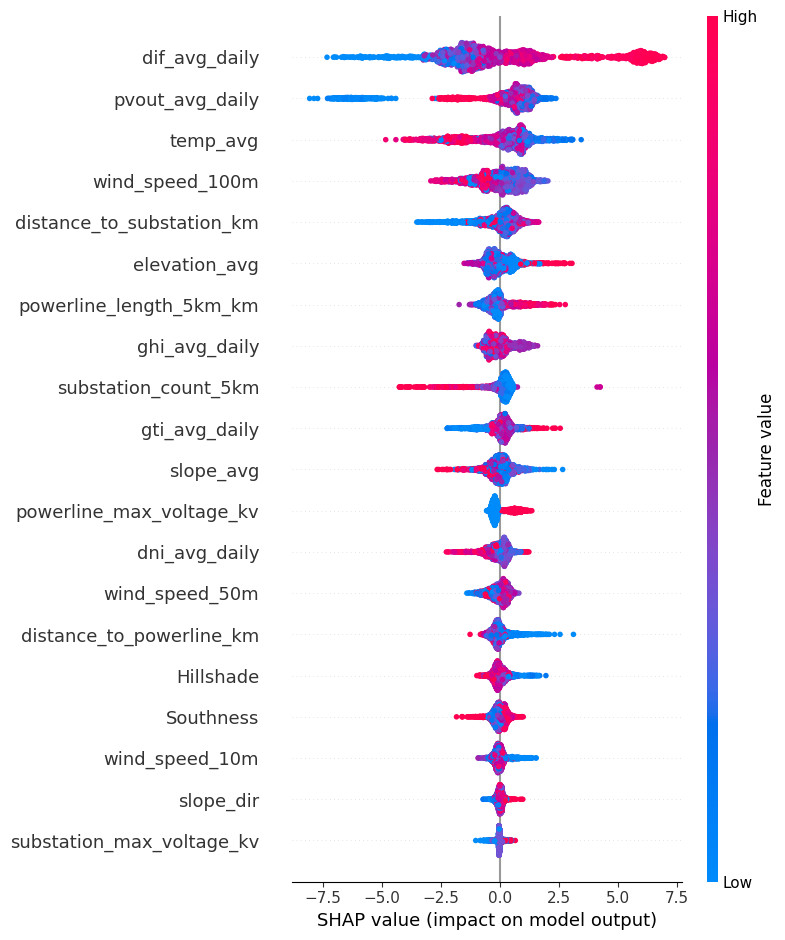

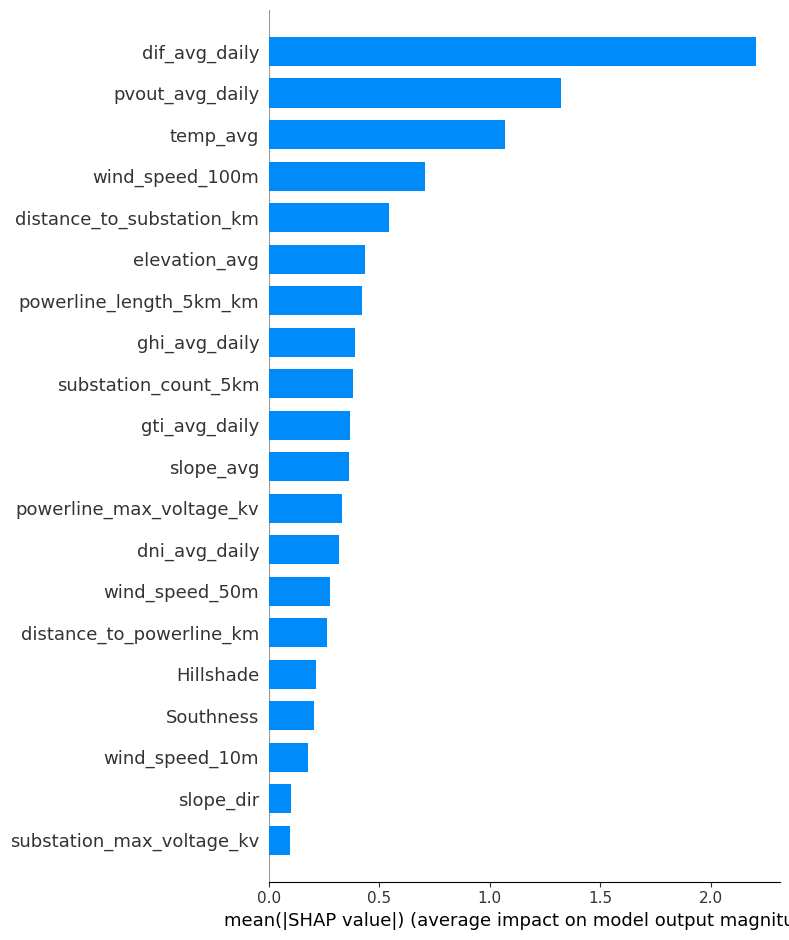

,Feature,Mean_Abs_SHAP
0,dif_avg_daily,2.2046
1,pvout_avg_daily,1.3230
2,temp_avg,1.0714
3,wind_speed_100m,0.7073
4,distance_to_substation_km,0.5449
5,elevation_avg,0.4344
6,powerline_length_5km_km,0.4193
7,ghi_avg_daily,0.3894
8,substation_count_5km,0.3827
9,gti_avg_daily,0.3660


In [52]:
shap_sample_n = min(SHAP_SAMPLE_SIZE, len(X_full))

X_shap = X_full.sample(
    n=shap_sample_n,
    random_state=RANDOM_STATE,
)

explainer = shap.TreeExplainer(final_model)
shap_result = explainer(X_shap)
shap_values = extract_positive_class_values(shap_result)

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURE_COLUMNS,
    show=False,
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "train_shap_summary_beeswarm.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURE_COLUMNS,
    plot_type="bar",
    show=False,
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "train_shap_summary_bar.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

global_shap_importance = (
    pd.DataFrame({
        "Feature": FEATURE_COLUMNS,
        "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0),
    })
    .sort_values("Mean_Abs_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(global_shap_importance)

global_shap_importance.to_csv(
    OUTPUT_DIR / "train_global_shap_importance.csv",
    index=False,
    encoding="utf-8-sig",
)


## 8. 결과 압축 및 다운로드

In [53]:
zip_path = Path(
    shutil.make_archive(
        "/content/building_model_training_results",
        "zip",
        OUTPUT_DIR,
    )
)

print("압축 완료:", zip_path)

from google.colab import files

# 모델 Bundle은 예측 노트북에 직접 사용합니다.
files.download(str(MODEL_BUNDLE_PATH))
files.download(str(zip_path))


압축 완료: /content/land_model_training_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>